# Your Fist Agent

In [1]:
# "자율형 AI", "지능형 에이전트", "AI 에이전트"
# 명령을 내리면 단순히 대답만 하는 챗봇(AI 어시스턴트)과 달리, 사람이 목표만 입력하면
# 스스로 생각(추론)하고, 계획을 세우며, 필요한 도구를 사용해 주도적으로 작업을 완료하는 소프트웨어 시스템

# import

In [2]:
import os
from langchain_openai.chat_models.base import ChatOpenAI
from langchain.messages import HumanMessage, SystemMessage, AIMessage
from pprint import pprint

from dotenv import load_dotenv
load_dotenv()

True

# LLM이 하지 못하는 것

In [3]:
llm = ChatOpenAI(temperature=0.1)

In [4]:
prompt = "Cost of $355.39 + $924.87 + $721.2 + $1940.29 + $573.63 + $65.72 + $35.00 + $552.00 + $76.16 + $29.12"


In [5]:
llm.invoke(prompt)

AIMessage(content='= $4923.38', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 59, 'total_tokens': 65, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Dvv5R6hQkIshspzayfZgUgJJmNZ7y', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f10fd-fb34-7cf0-af39-a8e490646338-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 6, 'total_tokens': 65, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [6]:
# 수식의 결과는 5273.38 이어야 하는데?
# 틀린 답
# 실시간 데이터 안됨.
# local데이터 안됨.

In [ ]:
# ⭐️LLM 은 산술연산을 할수 없다!!
# LLM은 '산술연산'을 수행하지 않습니다.  이런 계산은 AI보다 '계산기'가 더 잘한다!
# LLM 은 text 를 생성해내는 겁니다. 문장 시퀀스의 다음 token 이 무엇인지 통계적으로 추측하는 겁니다.

# 이러한 LLM 의 오류를 잡기위해선 agent 를 제공해주어야 한다.
# 그리고 agent 를 위한 tool(들) 을 만들고, agent 가 tool 을 선택해서 실행하는 것이다.


# Agent

## create_agent()

Creates an agent graph that calls tools in a loop until a stopping condition is met.


- `create_agent` 실제 운영 환경에서 사용 가능한 에이전트 구현을 제공합니다.
- Creates an agent graph that calls tools in a loop until a stopping condition is met.

- `create_agent` 는 LangGraph를 사용하여 그래프 기반 에이전트 런타임을 구축합니다 . 
- 그래프는 에이전트가 정보를 처리하는 방식을 정의하는 노드(단계)와 엣지(연결)로 구성됩니다. 
- 에이전트는 이 그래프를 따라 이동하며 모델 노드(모델을 호출), 도구 노드(도구를 실행), 미들웨어와 같은 노드를 실행합니다.

- https://reference.langchain.com/python/langchain/agents/?h=create_agent#langchain.agents.create_agent

- https://docs.langchain.com/oss/python/langchain/agents




```python
create_agent(
    model: str | BaseChatModel,
    tools: Sequence[BaseTool | Callable[..., Any] | dict[str, Any]] | None = None,  # A list of tools, dict, or Callable.
    *,
    system_prompt: str | SystemMessage | None = None,
    middleware: Sequence[AgentMiddleware[StateT_co, ContextT]] = (),
    response_format: ResponseFormat[ResponseT]
    | type[ResponseT]
    | dict[str, Any]
    | None = None,
    state_schema: type[AgentState[ResponseT]] | None = None,
    context_schema: type[ContextT] | None = None,
    checkpointer: Checkpointer | None = None,
    store: BaseStore | None = None,
    interrupt_before: list[str] | None = None,
    interrupt_after: list[str] | None = None,
    debug: bool = False,
    name: str | None = None,
    cache: BaseCache[Any] | None = None,
) -> CompiledStateGraph[
    AgentState[ResponseT], ContextT, _InputAgentState, _OutputAgentState[ResponseT]
]
```


![](https://mintcdn.com/langchain-5e9cc07a/Tazq8zGc0yYUYrDl/oss/images/core_agent_loop.png?w=1100&fit=max&auto=format&n=Tazq8zGc0yYUYrDl&q=85&s=88bef556edba9869b759551c610c60f4)

In [10]:
from langchain.agents import create_agent

## tool 준비

In [11]:
# agent에 전달할 tool 준비

# 함수 정의
def plus(a, b):
    return a + b

In [13]:
# 이 함수를 우리 agent 가 실제로 사용할수 있는 tool 로 변환해서 전달해주어야 한다
#   여기선 우린 StructuredTool 를 사용해보겠다.

In [12]:
from langchain_core.tools.structured import StructuredTool

# StructuredTool <- 매개변수를 여러개 받는 tool

In [35]:
agent = create_agent(
    model=ChatOpenAI(temperature=0.0,model='gpt-4o'),
    tools=[  # tool(들)을 전달
        StructuredTool.from_function(
            func=plus,  # 함수를 전달 -> tool 변환
            name="SumCalculator",  # tool 이름 지정 (📌공백불가)
            description="Use this to perform sum of two numbers. This tool take two arguments, both  should be numbers.",
        ),
    ],
)

type(agent)  # CompiledStateGraph 객체

langgraph.graph.state.CompiledStateGraph

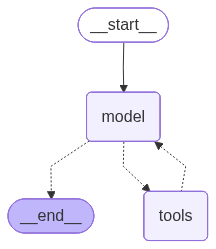

In [15]:
agent

### agent 호출
- agent 도 Runnable 객체 .  invoke() 있다.   chain 에서도 사용 가능.

In [36]:
result = agent.invoke({
    "messages": [
      {
          "role": "user",
          "content": "Cost of $355.39 + $924.87 + $721.2 + $1940.29 + $573.63 + $65.72 + $35.00 + $552.00 + $76.16 + $29.12",
      }  
    ],
})

result

{'messages': [HumanMessage(content='Cost of $355.39 + $924.87 + $721.2 + $1940.29 + $573.63 + $65.72 + $35.00 + $552.00 + $76.16 + $29.12', additional_kwargs={}, response_metadata={}, id='075b37a8-0e77-486c-b3b9-4ce24d0f7742'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 127, 'prompt_tokens': 114, 'total_tokens': 241, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1d93ca07c4', 'id': 'chatcmpl-DvwIe74z044p8UpWebnZ4ziab80aQ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f1145-24cb-7473-a6af-925b9afbe92e-0', tool_calls=[{'name': 'SumCalculator', 'args': {'a': 355.39, 'b': 924.87}, 'id': 'call_fePJtL4lsCN9KpEneQlk2TXk', 'type': 

In [17]:
type(result)

dict

In [18]:
result.keys()

dict_keys(['messages'])

In [20]:
result['messages']

[HumanMessage(content='Cost of $355.39 + $924.87 + $721.2 + $1940.29 + $573.63 + $65.72 + $35.00 + $552.00 + $76.16 + $29.12', additional_kwargs={}, response_metadata={}, id='46164ad2-f524-4bb1-923f-dabe183fc2b5'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 127, 'prompt_tokens': 114, 'total_tokens': 241, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1d93ca07c4', 'id': 'chatcmpl-Dvvk33vG4GnTyUrSnyXvDfXo2PrCq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f1124-612c-7821-af7e-79b96ac85261-0', tool_calls=[{'name': 'SumCalculator', 'args': {'a': 355.39, 'b': 924.87}, 'id': 'call_jsJqQciWZvHnpBXrYbHHdiYa', 'type': 'tool_call'}, 

In [21]:
result['messages'][-1].content

'The total cost is $5168.10.'

In [22]:
result['messages'][0]  # HumanMessage

HumanMessage(content='Cost of $355.39 + $924.87 + $721.2 + $1940.29 + $573.63 + $65.72 + $35.00 + $552.00 + $76.16 + $29.12', additional_kwargs={}, response_metadata={}, id='46164ad2-f524-4bb1-923f-dabe183fc2b5')

In [23]:
result['messages'][1]  # AIMessage

# content='' -> content 값이 없다
# tool_call=[] -> 주목 'tool 호출' 응답

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 127, 'prompt_tokens': 114, 'total_tokens': 241, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1d93ca07c4', 'id': 'chatcmpl-Dvvk33vG4GnTyUrSnyXvDfXo2PrCq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f1124-612c-7821-af7e-79b96ac85261-0', tool_calls=[{'name': 'SumCalculator', 'args': {'a': 355.39, 'b': 924.87}, 'id': 'call_jsJqQciWZvHnpBXrYbHHdiYa', 'type': 'tool_call'}, {'name': 'SumCalculator', 'args': {'a': 721.2, 'b': 1940.29}, 'id': 'call_y3lFJlFlkrrb4KCX9QdXP5qO', 'type': 'tool_call'}, {'name': 'SumCalculator', 'args': {'a': 573.63, 'b': 65.72}, 'id': 'call_3TZYICz1oPHzhZ91RF1V

In [24]:
result['messages'][1].tool_calls

[{'name': 'SumCalculator',
  'args': {'a': 355.39, 'b': 924.87},
  'id': 'call_jsJqQciWZvHnpBXrYbHHdiYa',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 721.2, 'b': 1940.29},
  'id': 'call_y3lFJlFlkrrb4KCX9QdXP5qO',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 573.63, 'b': 65.72},
  'id': 'call_3TZYICz1oPHzhZ91RF1V8Lut',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 35.0, 'b': 552.0},
  'id': 'call_AZoxcZqshLtQ9lcttjbdpBVG',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 76.16, 'b': 29.12},
  'id': 'call_CSveZxg5zz3oBmI2F7nhzfOK',
  'type': 'tool_call'}]

In [ ]:
# Agent에서 5번의 tool 호출이 이루어짐. 그 결과가 다음 5번의 ToolMessage 에 담김

result['messages'][2:7]

In [25]:
#  위 ToolMessage 가 AI 에 전달되고
#  AI 는 주어진 task 를 이루었는지 판단함.

result['messages'][7]  # AIMessage

# content=''
# 'finish_reason': 'tool_calls'
# tool_calls=[]

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 278, 'total_tokens': 360, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1d93ca07c4', 'id': 'chatcmpl-Dvvk5cnNAIwLOjqxXiHOC8DmfUc3l', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f1124-726d-7483-876d-baba180208fa-0', tool_calls=[{'name': 'SumCalculator', 'args': {'a': 1280.26, 'b': 2661.49}, 'id': 'call_yxS1wEFhBD3hC0JoaFzmkZIQ', 'type': 'tool_call'}, {'name': 'SumCalculator', 'args': {'a': 639.35, 'b': 587.0}, 'id': 'call_QgYGOMbpy35csVgEG5FDERdV', 'type': 'tool_call'}, {'name': 'SumCalculator', 'args': {'a': 105.28, 'b': 0}, 'id': 'call_YXyg1DTmuJzK5r7OuvGsx4Ze

In [26]:
result['messages'][7].tool_calls

[{'name': 'SumCalculator',
  'args': {'a': 1280.26, 'b': 2661.49},
  'id': 'call_yxS1wEFhBD3hC0JoaFzmkZIQ',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 639.35, 'b': 587.0},
  'id': 'call_QgYGOMbpy35csVgEG5FDERdV',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 105.28, 'b': 0},
  'id': 'call_YXyg1DTmuJzK5r7OuvGsx4Ze',
  'type': 'tool_call'}]

In [27]:
result['messages'][8:11]

[ToolMessage(content='3941.75', name='SumCalculator', id='78e5a23a-e132-419b-93c8-56fd048b525b', tool_call_id='call_yxS1wEFhBD3hC0JoaFzmkZIQ'),
 ToolMessage(content='1226.35', name='SumCalculator', id='da95aeef-e7fe-4d19-ae6d-6e7443da102b', tool_call_id='call_QgYGOMbpy35csVgEG5FDERdV'),
 ToolMessage(content='105.28', name='SumCalculator', id='d081f59c-4b2c-43bd-adf9-663613d7011e', tool_call_id='call_YXyg1DTmuJzK5r7OuvGsx4Ze')]

In [28]:
result['messages'][11]

# 'finish_reason': 'tool_calls'
# tool_calls=[]

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 387, 'total_tokens': 411, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1d93ca07c4', 'id': 'chatcmpl-Dvvk7ii4rAl3pb2DE4VQJV68ayy5R', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f1124-799b-7ec3-965b-92ef607adb70-0', tool_calls=[{'name': 'SumCalculator', 'args': {'a': 3941.75, 'b': 1226.35}, 'id': 'call_0AdrkpX7ADXdyuJRnr21VPI8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 387, 'output_tokens': 24, 'total_tokens': 411, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [29]:
result['messages'][11].tool_calls

[{'name': 'SumCalculator',
  'args': {'a': 3941.75, 'b': 1226.35},
  'id': 'call_0AdrkpX7ADXdyuJRnr21VPI8',
  'type': 'tool_call'}]

In [30]:
result['messages'][12:13]

[ToolMessage(content='5168.1', name='SumCalculator', id='564a475c-dfa7-4661-a5f0-cfdd7eb786bf', tool_call_id='call_0AdrkpX7ADXdyuJRnr21VPI8')]

In [32]:
result['messages'][13]

# content='The total cost is $5168.10.'
# 'finish_reason': 'stop'

AIMessage(content='The total cost is $5168.10.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 423, 'total_tokens': 434, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1d93ca07c4', 'id': 'chatcmpl-Dvvk8OwlsLp8nwjrjrZxcteXHy3Rx', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f1124-7c88-7b92-85f1-7be9065fc69f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 423, 'output_tokens': 11, 'total_tokens': 434, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## 도구 함수의 기본값, typehint

In [ ]:
def plus(a: float, b: float= 0) -> float:
    """두 수를 더한다. b가 없으면 0으로 처리한다."""
    return a + b

agent = create_agent(
    model = ChatOpenAI(temperature=0.0, model='gpt-4o'),
    tools = [  # tool(들) 전달
        StructuredTool.from_function(
            func=plus,   # 함수를 전달 -> tool 변환
            name="SumCalculator",  # tool 이름 지정 (📌 공백불가)
            description=(
                "Use this tool to sum two numbers. The second number (b) is optional "
                "and defaults to 0 if not provided — so calling it with only one number "
                "simply returns that number." 
            )
        ),
    ]
)

result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Cost of $355.39 + $924.87 + $721.2 + $1940.29 + $573.63 + $65.72 + $35.00 + $552.00 + $76.16 + $29.12",
        }
    ],
})

result['messages'][-1].content

In [37]:
"최" "홍" "묵"

'최홍묵'

### 왜 이렇게 동작하나
- `StructuredTool.from_function`은 `func`의 시그니처를 inspect 해서 args_schema(pydantic 모델)를 자동 생성합니다.
- `b: float = 0`처럼 기본값이 있으면 pydantic 필드도 `required=False, default=0`이 되고, 이게 그대로 OpenAI function-calling용 JSON Schema에 반영되어 `"required": ["a"]`만 남게 됩니다.
- 따라서 GPT-4o가 `b`를 채우지 않고 `{"a": 5}`만 호출해도 LangChain이 함수 실행 시 `plus(a=5)` → 기본값 `b=0`이 적용되어 정상 동작합니다.

### 참고: 타입힌트가 중요한 이유
원래 코드처럼 `def plus(a, b):`로 타입힌트가 없으면 스키마상 타입이 모호해져(Any로 추론) GPT가 문자열을 넘기는 등 타입 불일치가 생길 수 있습니다. `float`(또는 `int`)로 명시해주는 게 안전합니다.

### 만약 원본 `plus` 함수를 수정할 수 없는 경우
기본값을 못 넣는 상황이라면 래퍼 함수를 만들어 그걸 `func`로 넘기면 됩니다.

```python
def plus_wrapper(a: float, b: float = 0) -> float:
    return plus(a, b)  # 원본 plus 호출

tool = StructuredTool.from_function(
    func=plus_wrapper,
    name="SumCalculator",
    description="...",  # 위와 동일
)
```
